In [ ]:
import torch
print('GPU:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('이름:', torch.cuda.get_device_name(0))

GPU: True
이름: Tesla T4


In [ ]:
!pip install -q datasets
from datasets import load_dataset

pet = load_dataset("timm/oxford-iiit-pet")
print(pet)

README.md:   0%|          | 0.00/2.50k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  378MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  413MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/3680 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3669 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'image_id', 'label_cat_dog'],
        num_rows: 3680
    })
    test: Dataset({
        features: ['image', 'label', 'image_id', 'label_cat_dog'],
        num_rows: 3669
    })
})


In [ ]:
import torch
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader

# 먼저 필드 이름과 클래스 수 확인
print(pet['train'].features)
print('클래스 수:', len(pet['train'].features['label'].names))

{'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['abyssinian', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'bengal', 'birman', 'bombay', 'boxer', 'british_shorthair', 'chihuahua', 'egyptian_mau', 'english_cocker_spaniel', 'english_setter', 'german_shorthaired', 'great_pyrenees', 'havanese', 'japanese_chin', 'keeshond', 'leonberger', 'maine_coon', 'miniature_pinscher', 'newfoundland', 'persian', 'pomeranian', 'pug', 'ragdoll', 'russian_blue', 'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu', 'siamese', 'sphynx', 'staffordshire_bull_terrier', 'wheaten_terrier', 'yorkshire_terrier']), 'image_id': Value('string'), 'label_cat_dog': ClassLabel(names=['cat', 'dog'])}
클래스 수: 37


In [ ]:
MEAN = (0.485, 0.456, 0.406)   # ImageNet 표준값
STD  = (0.229, 0.224, 0.225)

train_tf = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])
test_tf = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

class PetHF(Dataset):
    def __init__(self, split, transform=None):
        self.ds = pet[split]
        self.transform = transform
        self.classes = self.ds.features['label'].names

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        item = self.ds[idx]
        img, label = item['image'], item['label']
        if img.mode != 'RGB':          # 흑백 이미지가 섞여 있어 통일 필요
            img = img.convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

ds_train = PetHF('train', train_tf)
ds_test  = PetHF('test',  test_tf)

In [ ]:
print('train:', len(ds_train), '| test:', len(ds_test))
print('클래스 수:', len(ds_train.classes))

img, label = ds_train[0]
print('이미지 shape:', img.shape)      # torch.Size([3, 224, 224])
print('값 범위: %.2f ~ %.2f' % (img.min(), img.max()))

train: 3680 | test: 3669
클래스 수: 37
이미지 shape: torch.Size([3, 224, 224])
값 범위: -2.07 ~ 2.08


In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

imgs, labels = next(iter(train_loader))
print(imgs.shape)   # torch.Size([32, 3, 224, 224])

torch.Size([32, 3, 224, 224])


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class BasicBlock(nn.Module):
    expansion = 1   # 출력 채널이 입력의 몇 배인지

    def __init__(self, in_ch, out_ch, stride=1, use_skip=True):
        super().__init__()
        self.use_skip = use_skip

        # 메인 경로: 3×3 → 3×3
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)

        # 지름길: 크기나 채널이 바뀔 때만 1×1로 맞춰줌
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.use_skip:                 # ← 이 한 줄이 ResNet vs Plain을 가름
            out = out + self.shortcut(x)
        return F.relu(out)

In [ ]:
class Bottleneck(nn.Module):
    expansion = 4   # 마지막에 채널을 4배로 늘림

    def __init__(self, in_ch, mid_ch, stride=1, use_skip=True):
        super().__init__()
        self.use_skip = use_skip
        out_ch = mid_ch * self.expansion

        # 메인 경로: 1×1(줄이고) → 3×3 → 1×1(4배로 늘리고)
        self.conv1 = nn.Conv2d(in_ch, mid_ch, 1, bias=False)
        self.bn1   = nn.BatchNorm2d(mid_ch)
        self.conv2 = nn.Conv2d(mid_ch, mid_ch, 3, stride=stride, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(mid_ch)
        self.conv3 = nn.Conv2d(mid_ch, out_ch, 1, bias=False)
        self.bn3   = nn.BatchNorm2d(out_ch)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        if self.use_skip:
            out = out + self.shortcut(x)
        return F.relu(out)

In [ ]:
# 크기 유지되는 경우
b1 = BasicBlock(64, 64, stride=1)
x = torch.randn(1, 64, 56, 56)
print('BasicBlock 유지 :', tuple(b1(x).shape))    # (1, 64, 56, 56)

# 크기 절반 + 채널 2배
b2 = BasicBlock(64, 128, stride=2)
print('BasicBlock 다운 :', tuple(b2(x).shape))    # (1, 128, 28, 28)

# Bottleneck (mid 64 → 출력 256)
b3 = Bottleneck(64, 64, stride=1)
print('Bottleneck     :', tuple(b3(x).shape))     # (1, 256, 56, 56)

BasicBlock 유지 : (1, 64, 56, 56)
BasicBlock 다운 : (1, 128, 28, 28)
Bottleneck     : (1, 256, 56, 56)


In [ ]:
class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=37, use_skip=True):
        super().__init__()
        self.in_ch = 64

        # 1) Stem: 224 → 56으로 빠르게 축소
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1),
        )

        # 2) 4개 스테이지
        self.layer1 = self._make_stage(block, 64,  num_blocks[0], stride=1, use_skip=use_skip)
        self.layer2 = self._make_stage(block, 128, num_blocks[1], stride=2, use_skip=use_skip)
        self.layer3 = self._make_stage(block, 256, num_blocks[2], stride=2, use_skip=use_skip)
        self.layer4 = self._make_stage(block, 512, num_blocks[3], stride=2, use_skip=use_skip)

        # 3) 분류부
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_stage(self, block, mid_ch, n, stride, use_skip):
        # 첫 블록만 stride 적용(크기 축소), 나머지는 stride 1
        strides = [stride] + [1] * (n - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_ch, mid_ch, stride=s, use_skip=use_skip))
            self.in_ch = mid_ch * block.expansion   # 다음 블록의 입력 채널 갱신
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x); x = self.layer3(x); x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

In [ ]:
def build_resnet34(num_classes=37, use_skip=True):
    return ResNet(BasicBlock, [3, 4, 6, 3], num_classes, use_skip)

def build_resnet50(num_classes=37, use_skip=True):
    return ResNet(Bottleneck, [3, 4, 6, 3], num_classes, use_skip)

In [ ]:
!pip install -q torchinfo
from torchinfo import summary

In [ ]:
# ResNet-34
summary(build_resnet34(use_skip=True), input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 37]                   --
├─Sequential: 1-1                        [1, 64, 56, 56]           --
│    └─Conv2d: 2-1                       [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                  [1, 64, 112, 112]         128
│    └─ReLU: 2-3                         [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                    [1, 64, 56, 56]           --
├─Sequential: 1-2                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-5                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─Conv2d: 3-3                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-4             [1, 64, 56, 56]           128
│    │    └─Sequential: 3-5              [1, 64, 56, 56]           --
│

In [ ]:
# ResNet-50
summary(build_resnet50(use_skip=True), input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 37]                   --
├─Sequential: 1-1                        [1, 64, 56, 56]           --
│    └─Conv2d: 2-1                       [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                  [1, 64, 112, 112]         128
│    └─ReLU: 2-3                         [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                    [1, 64, 56, 56]           --
├─Sequential: 1-2                        [1, 256, 56, 56]          --
│    └─Bottleneck: 2-5                   [1, 256, 56, 56]          --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           4,096
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─Conv2d: 3-3                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-4             [1, 64, 56, 56]           128
│    │    └─Conv2d: 3-5                  [1, 256, 56, 56]          16,38

In [ ]:
models = {
    'ResNet-34': build_resnet34(use_skip=True),
    'Plain-34':  build_resnet34(use_skip=False),
    'ResNet-50': build_resnet50(use_skip=True),
    'Plain-50':  build_resnet50(use_skip=False),
}

for name, m in models.items():
    conv = sum(1 for mod in m.modules() if isinstance(mod, nn.Conv2d))
    params = sum(p.numel() for p in m.parameters())
    print(f'{name:10s} | conv {conv:2d}개 | 파라미터 {params:,}')

ResNet-34  | conv 36개 | 파라미터 21,303,653
Plain-34   | conv 36개 | 파라미터 21,303,653
ResNet-50  | conv 53개 | 파라미터 23,583,845
Plain-50   | conv 53개 | 파라미터 23,583,845


In [ ]:
x = torch.randn(2, 3, 224, 224)
for name, m in models.items():
    print(f'{name:10s} 출력: {tuple(m(x).shape)}')   # 전부 (2, 37)

ResNet-34  출력: (2, 37)
Plain-34   출력: (2, 37)
ResNet-50  출력: (2, 37)
Plain-50   출력: (2, 37)


In [ ]:
import time

device = 'cuda' if torch.cuda.is_available() else 'cpu'

def train_model(model, train_loader, test_loader, epochs=5, lr=1e-3, name='model'):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for ep in range(1, epochs + 1):
        t0 = time.time()

        model.train()
        running = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimizer.step()
            running += loss.item() * imgs.size(0)
        train_loss = running / len(train_loader.dataset)

        model.eval()
        running, correct = 0.0, 0
        with torch.no_grad():
            for imgs, labels in test_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out = model(imgs)
                running += criterion(out, labels).item() * imgs.size(0)
                correct += (out.argmax(1) == labels).sum().item()
        val_loss = running / len(test_loader.dataset)
        val_acc  = correct / len(test_loader.dataset)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        elapsed = time.time() - t0
        print(f'[{name}] {ep}/{epochs}  train_loss {train_loss:.4f} | val_acc {val_acc:.4f} | {elapsed:.0f}s')

    return history

In [ ]:
test50 = build_resnet50(use_skip=True)
_ = train_model(test50, train_loader, test_loader, epochs=1, name='시간측정')

[시간측정] 1/1  train_loss 3.8995 | val_acc 0.0300 | 65s


In [ ]:
EPOCHS = 5
results = {}

for name, builder, skip in [
    ('ResNet-34', build_resnet34, True),
    ('Plain-34',  build_resnet34, False),
    ('ResNet-50', build_resnet50, True),
    ('Plain-50',  build_resnet50, False),
]:
    print(f'\n===== {name} 학습 시작 =====')
    model = builder(use_skip=skip)
    results[name] = train_model(model, train_loader, test_loader,
                                epochs=EPOCHS, name=name)


===== ResNet-34 학습 시작 =====
[ResNet-34] 1/5  train_loss 3.7412 | val_acc 0.0578 | 43s
[ResNet-34] 2/5  train_loss 3.5192 | val_acc 0.0662 | 41s
[ResNet-34] 3/5  train_loss 3.4289 | val_acc 0.0760 | 42s
[ResNet-34] 4/5  train_loss 3.3489 | val_acc 0.0973 | 41s
[ResNet-34] 5/5  train_loss 3.2731 | val_acc 0.0886 | 41s

===== Plain-34 학습 시작 =====
[Plain-34] 1/5  train_loss 3.6537 | val_acc 0.0305 | 41s
[Plain-34] 2/5  train_loss 3.6064 | val_acc 0.0422 | 41s
[Plain-34] 3/5  train_loss 3.5661 | val_acc 0.0455 | 41s
[Plain-34] 4/5  train_loss 3.5334 | val_acc 0.0444 | 41s
[Plain-34] 5/5  train_loss 3.5166 | val_acc 0.0466 | 41s

===== ResNet-50 학습 시작 =====
[ResNet-50] 1/5  train_loss 3.8844 | val_acc 0.0444 | 63s
[ResNet-50] 2/5  train_loss 3.5642 | val_acc 0.0559 | 62s
[ResNet-50] 3/5  train_loss 3.4548 | val_acc 0.0540 | 62s
[ResNet-50] 4/5  train_loss 3.3857 | val_acc 0.0766 | 63s
[ResNet-50] 5/5  train_loss 3.3325 | val_acc 0.1071 | 61s

===== Plain-50 학습 시작 =====
[Plain-50] 1/5  train

In [ ]:
print(f'{"모델":12s} {"최종 val_acc":>12s} {"최고 val_acc":>12s}')
print('-' * 38)
for name, h in results.items():
    print(f'{name:12s} {h["val_acc"][-1]:>12.4f} {max(h["val_acc"]):>12.4f}')

모델             최종 val_acc   최고 val_acc
--------------------------------------
ResNet-34          0.0886       0.0973
Plain-34           0.0466       0.0466
ResNet-50          0.1071       0.1071
Plain-50           0.0371       0.0371


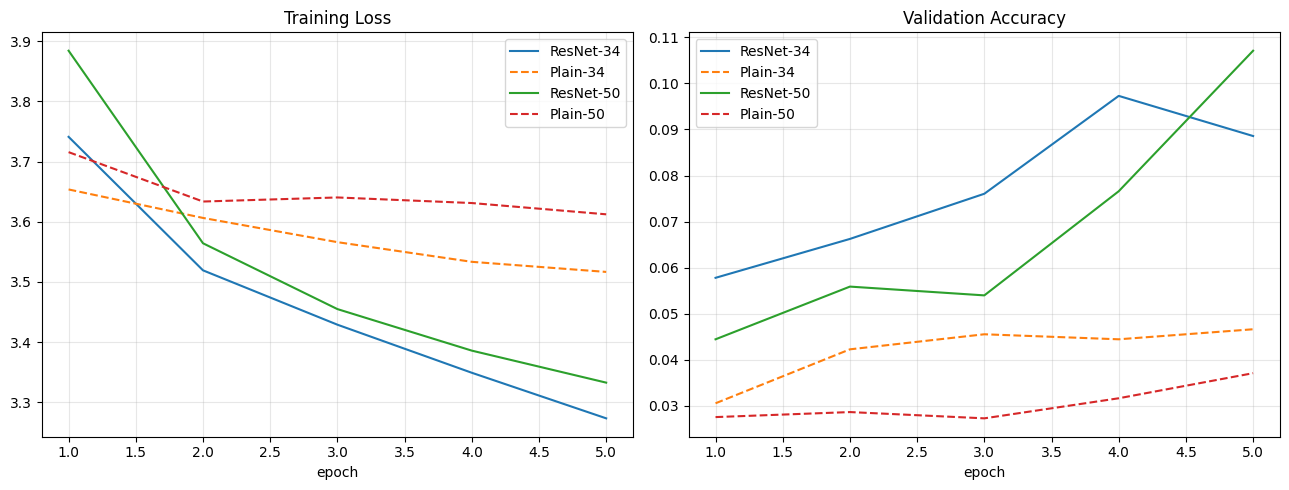

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ep = range(1, EPOCHS + 1)

for name, h in results.items():
    style = '-' if 'ResNet' in name else '--'   # ResNet 실선, Plain 점선
    axes[0].plot(ep, h['train_loss'], style, label=name)
    axes[1].plot(ep, h['val_acc'],    style, label=name)

axes[0].set_title('Training Loss'); axes[0].set_xlabel('epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title('Validation Accuracy'); axes[1].set_xlabel('epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()